# 🛒 Superstore Sales Analysis
## Retail Performance Analysis — United States

### Business Question
Which regions and product categories drive the most revenue,
and how do sales patterns vary by season?

### Dataset
- Source: Kaggle — Superstore Sales Dataset
- Size: 9,800 rows × 18 columns
- Period: 2014–2017

### Tools
- Python (Pandas, Matplotlib)
- Jupyter Notebook / Google Colab

### Key Questions
1. Which region generates the most sales?
2. Which category and sub-category is most profitable?
3. What are the monthly and quarterly sales trends?
4. Who are the most valuable customers?
5. Which customer segment spends the most?

Executive Summary
This analysis of 9,800 Superstore transactions (2014-2017) reveals:

💰 Total Revenue:  2,261,536−🏆∗∗TopRegion:∗∗West( 710,219)
📦 Top Category: Technology ( 827,455)−👤∗∗TopCustomer:∗∗SeanMiller( 25,043)
📈 Best Month: November ( 350,161)−📉∗∗WorstMonth:∗∗February( 59,371)
🔝 Best Quarter: Q4 ($871,138)
👥 Dominant Segment: Consumer (58% of revenue)

In [21]:
import zipfile

with zipfile.ZipFile('/content/superstore.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("✅ Archivo descomprimido")

✅ Archivo descomprimido


In [22]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Display format
pd.options.display.float_format = '{:,.2f}'.format

# Load dataset

df = pd.read_csv('/content/train.csv', encoding='latin1')
print("Dataset loaded successfully")
print(f"shape: {df.shape}")
print(f"columns: {list(df.columns)}")

Dataset loaded successfully
shape: (9800, 18)
columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [23]:
# First look at the data
print("First 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product 

## Data Cleaning

### Issues Found:
- Order Date and Ship Date are stored as strings → need to convert to datetime
- Postal Code has 11 missing values → will fill with 0
- Sales column has outliers mean ($230 vs median $54)

In [6]:
# Convert dates to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Fill missing Postal Code values
df['Postal Code'] = df['Postal Code'].fillna(0)

# Verify cleaning
print("✅ Data cleaning complete")
print(f"\nOrder Date type: {df['Order Date'].dtype}")
print(f"Ship Date type: {df['Ship Date'].dtype}")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())

✅ Data cleaning complete

Order Date type: datetime64[ns]
Ship Date type: datetime64[ns]

Missing values after cleaning:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


## Analysis

### Question 1: Which region generates the most sales?

In [7]:
region_count = df['Region'].value_counts()
print("Number of Orders by Region:")
print(region_count)
print("\nTotal Sales by Region:")

region_group = df.groupby('Region')['Sales'].sum()
print(region_group)

region_group = df.groupby('Region')['Sales'].sum()
region_sales_sorted = region_group.sort_values(ascending=False)

top3_best = region_sales_sorted.head(3)

print("\nTop 3 best regions:")
print(top3_best)

Number of Orders by Region:
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

Total Sales by Region:
Region
Central   492,646.91
East      669,518.73
South     389,151.46
West      710,219.68
Name: Sales, dtype: float64

Top 3 best regions:
Region
West      710,219.68
East      669,518.73
Central   492,646.91
Name: Sales, dtype: float64


### Key Finding — Region Analysis:
- West region generates the highest revenue ($710,219) despite having
  fewer orders than East, suggesting higher-value purchases per transaction.
- South region has the lowest sales ($389,151) — opportunity for growth.

### Question 2: Which category and sub-category generates the most sales?

In [8]:
category_count = df['Category'].value_counts()
print("Number of Orders by Category:")
print(category_count)
print("\nCategory Sales:")

category_group = df.groupby('Category')['Sales'].sum()
print(category_group)

category_group = df.groupby('Category')['Sales'].sum()
category_sales_sorted = category_group.sort_values(ascending=False)

top3_best = category_sales_sorted.head(3)

print("\nTop 3 best Categories:")
print(top3_best)

Number of Orders by Category:
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

Category Sales:
Category
Furniture         728,658.58
Office Supplies   705,422.33
Technology        827,455.87
Name: Sales, dtype: float64

Top 3 best Categories:
Category
Technology        827,455.87
Furniture         728,658.58
Office Supplies   705,422.33
Name: Sales, dtype: float64


### Key Finding — Category Analysis:
- Technology generates the most revenue ($827K) despite having
  the fewest orders (1,813).
- Office Supplies has the most orders (5,909) but ranks last in revenue
  — products have a low price per unit.

In [9]:
sub_category_count = df['Sub-Category'].value_counts()
print("Number of orders by Sub-Category:")
print(sub_category_count)
print("\nTotal Sales by Sub-Category:")

sub_category_group = df.groupby('Sub-Category')['Sales'].sum()
print(sub_category_group)

sub_category_group = df.groupby('Sub-Category')['Sales'].sum()
sub_category_sales_sorted = sub_category_group.sort_values(ascending=False)

top3_best = sub_category_sales_sorted.head(5)

print("\nTop 5 best Sub-Categories:")
print(top3_best)

Number of orders by Sub-Category:
Sub-Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64

Total Sales by Sub-Category:
Sub-Category
Accessories   164,186.70
Appliances    104,618.40
Art            26,705.41
Binders       200,028.79
Bookcases     113,813.20
Chairs        322,822.73
Copiers       146,248.09
Envelopes      16,128.05
Fasteners       3,001.96
Furnishings    89,212.02
Labels         12,347.73
Machines      189,238.63
Paper          76,828.30
Phones        327,782.45
Storage       219,343.39
Supplies       46,420.31
Tables        202,810.63
Name: Sales, dtype: float64

Top 5 best Sub-Categories:
Sub-Category
Phones    327,782.45
Chairs    322,822.73
Storage 

### Key Finding — Sub-Category Analysis:
- Phones and Chairs are the top revenue-generating sub-categories ($327K and $322K).
- Binders have the most orders (1,492) but rank 5th in revenue — low price per unit.
- Fasteners generate the least revenue ($3,001) despite 214 orders.

### Question 3: What are the monthly and quarterly sales trends?

In [10]:
# Create Month and Quarter columns
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

# Monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()
print("Monthly Sales:")
print(monthly_sales)


# Quarterly Sales
quarterly_sales = df.groupby('Quarter')['Sales'].sum()
print("\nQuarterly Sales:")
print(quarterly_sales)

Monthly Sales:
Month
1     94,291.63
2     59,371.12
3    197,573.59
4    136,283.00
5    154,086.72
6    145,837.52
7    145,535.69
8    157,315.93
9    300,103.41
10   199,496.29
11   350,161.71
12   321,480.17
Name: Sales, dtype: float64

Quarterly Sales:
Quarter
1   351,236.33
2   436,207.25
3   602,955.03
4   871,138.18
Name: Sales, dtype: float64


### Key Finding — Sales Trends:
- Q4 (October-December) dominates with $871K in sales — likely driven
  by Black Friday and Christmas season.
- November is the strongest month ($350K) and February the weakest ($59K).
- Q1 is the slowest quarter — opportunity to create promotions to
  boost January and February sales.

### Question 4: Who are the most valuable customers?

In [11]:
# Top 5 most valuable customers by total sales

customer_name_count = df['Customer Name'].value_counts()
print(customer_name_count)
customer_name_group = df.groupby('Customer Name')['Sales'].sum()
print(customer_name_group)
sorted_sales = customer_name_group.sort_values(ascending=False)
top5_best = sorted_sales.head(5)
print("\nTop 5 best Customers:")
print(top5_best)

Customer Name
William Brown       35
Matt Abelman        34
Paul Prost          34
John Lee            33
Jonathan Doherty    32
                    ..
Lela Donovan         1
Jocasta Rupert       1
Carl Jackson         1
Sung Chung           1
Ricardo Emerson      1
Name: count, Length: 793, dtype: int64
Customer Name
Aaron Bergman          886.16
Aaron Hawkins        1,744.70
Aaron Smayling       3,050.69
Adam Bellavance      7,755.62
Adam Hart            3,250.34
                       ...   
Xylona Preis         2,374.66
Yana Sorensen        6,720.44
Yoseph Carroll       5,454.35
Zuschuss Carroll     8,025.71
Zuschuss Donatelli   1,493.94
Name: Sales, Length: 793, dtype: float64

Top 5 best Customers:
Customer Name
Sean Miller     25,043.05
Tamara Chand    19,052.22
Raymond Buch    15,117.34
Tom Ashbrook    14,595.62
Adrian Barton   14,473.57
Name: Sales, dtype: float64


### Key Finding — Top Customers:
- Sean Miller is the most valuable customer with $25,043 in total purchases.
- The top 5 customers represent a significant portion of total revenue
  — retaining them should be a priority for the business.

### Question 5: Which customer segment spends the most?

In [12]:
# Customer segment analysis

segment_count = df['Segment'].value_counts()
print("Number of Orders by Segment:")
print(segment_count)

segment_group = df.groupby('Segment')['Sales'].sum()
print("\nTotal Sales by Segment:")
print(segment_group)

segment_sales_sorted = segment_group.sort_values(ascending=False)
print("\nSales Ranking by Segment:")
print(segment_sales_sorted)

Number of Orders by Segment:
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

Total Sales by Segment:
Segment
Consumer      1,148,060.53
Corporate       688,494.07
Home Office     424,982.18
Name: Sales, dtype: float64

Sales Ranking by Segment:
Segment
Consumer      1,148,060.53
Corporate       688,494.07
Home Office     424,982.18
Name: Sales, dtype: float64


### Key Finding — Customer Segments:
- Consumer segment dominates with $1,148,060 in sales (58% of total revenue).
- Home Office is the smallest segment but has a higher average sale
  value than Corporate.
- Corporate segment represents an opportunity for growth through
  targeted B2B strategies.

## Data Visualization

### Chart 1: Total Sales by Region

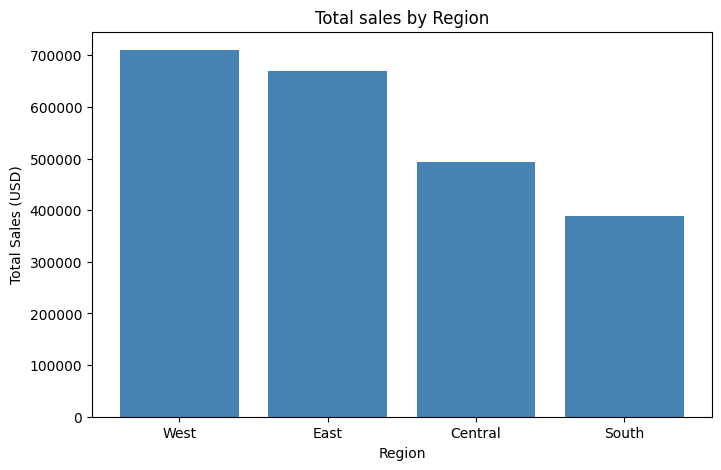

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(region_sales_sorted.index, region_sales_sorted.values, color='steelblue', label='Monthly Sales' )
plt.title('Total sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales (USD)')
plt.show()

### Chart 2: Total Sales by Category

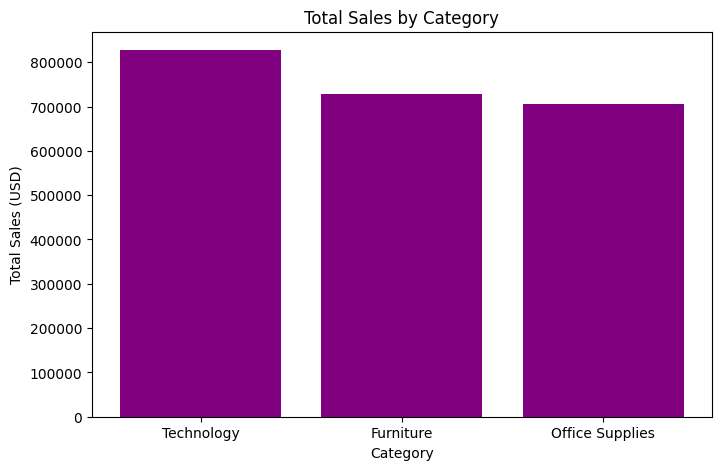

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(category_sales_sorted.index, category_sales_sorted.values, color='purple', label='Categories' )
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales (USD)')
plt.show()

### Chart 3: Monthly Sales Trend

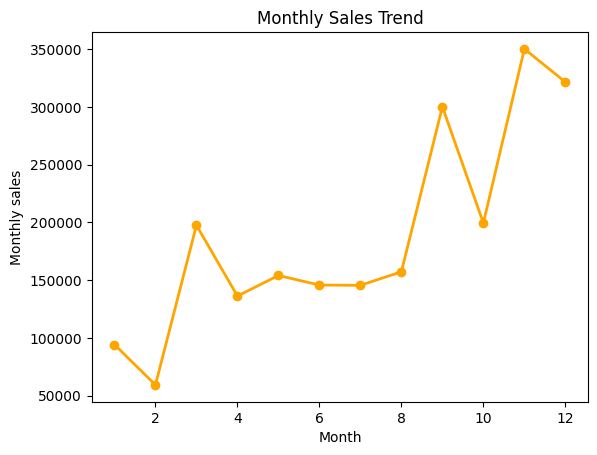

In [15]:
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', linewidth = 2, color='orange')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Monthly sales')
plt.show()

### Chart 4: Quarterly Sales

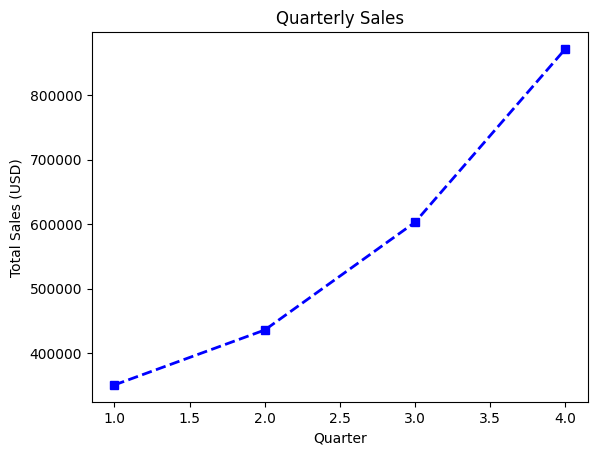

In [17]:
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='s', linestyle='--', linewidth = 2, color='blue')

plt.title('Quarterly Sales')
plt.xlabel('Quarter')
plt.ylabel('Total Sales (USD)')
plt.show()

### Chart 5: Top 5 Most Valuable Customers

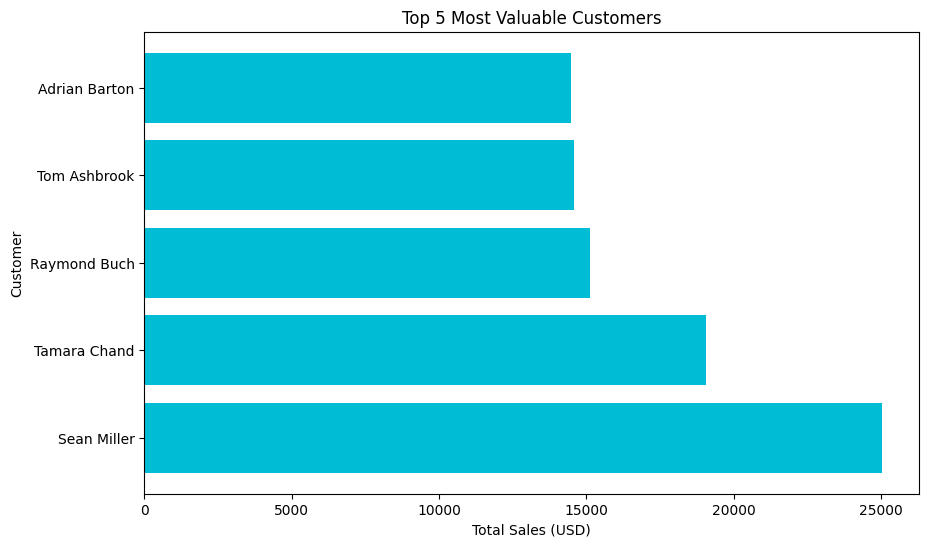

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(top5_best.index, top5_best.values, color='#00BCD4', label='Top 5 Most Valuable Customers')

plt.title('Top 5 Most Valuable Customers')
plt.ylabel('Customer')
plt.xlabel('Total Sales (USD)')
plt.show()

### Chart 6: Sales by Customer Segment

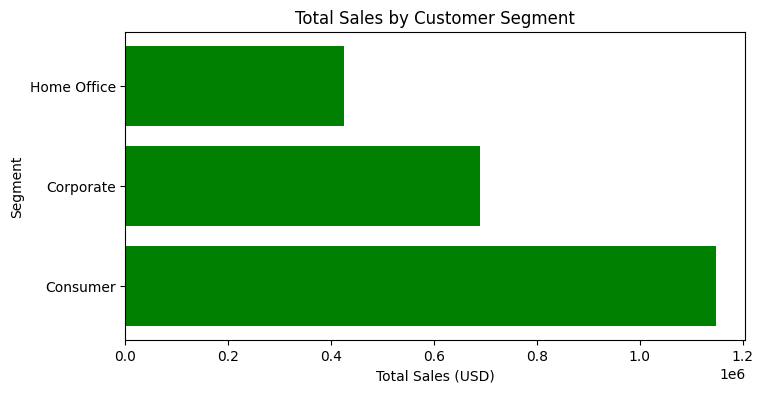

In [20]:
plt.figure(figsize=(8, 4))

plt.barh(segment_sales_sorted.index, segment_sales_sorted.values, color='green', label='Customer Segment')

plt.title('Total Sales by Customer Segment')
plt.ylabel('Segment')
plt.xlabel('Total Sales (USD)')
plt.show()

## Conclusions & Recommendations

### Key Findings:
1. West region generates the highest revenue ($710K) with fewer orders
   than East — higher value per transaction.
2. Technology is the top category ($827K) despite fewer orders than
   Office Supplies.
3. Q4 dominates sales ($871K) — driven by Black Friday and Christmas season.
4. Sean Miller is the most valuable customer ($25K in total purchases).
5. Consumer segment represents 58% of total revenue ($1.14M).

### Recommendations:
1. Invest in Q1 promotions to boost the weakest quarter (Feb: $59K).
2. Focus marketing efforts on the West and East regions.
3. Create loyalty programs for top customers like Sean Miller.
4. Expand Technology product offerings — highest revenue per order.
5. Target Corporate segment for B2B growth opportunities.